# **프로젝트: 트랜스포머로 만드는 대화형 챗봇**

#### **프로젝트 개요**  

**1. 프로젝트 목적:**  

GPT-1 (Generative Pre-trained Transformer) 논문을 기반으로 GPT 모델의 비지도 사전 학습 단계를 구현한다.

**2. 데이터셋: 🤖 [한국어 챗봇 데이터](https://github.com/songys/Chatbot_data/tree/master?tab=readme-ov-file) (송영숙님 제공)**  

- 일상, 이별, 사랑 등 3가지 테마로 구성된 약 11,823개의 한국어 Q&A 쌍
- SentencePiece를 사용하여 한국어 특성에 맞는 서브워드(Subword) 토큰화 적용


**3. 트랜스포머 vs. GPT-1:**  
<br>

| 구분 | Transformer | GPT-1 |
|------|----------------------|-------|
| 구조 | Encoder-Decoder (seq2seq) | Decoder-only |
| 어텐션 | Self-Attention + Cross-Attention | Masked Self-Attention |
| 입력 형태 | 질문(Q)과 답변(A) 분리 | 단일 텍스트 시퀀스 |
| 학습 목표 | 질문→답변 생성 | 다음 토큰 예측 (Causal LM) |
| 데이터 전처리 | Q, A 별도 토큰화 | 연속된 텍스트로 처리 |  


<br>
데이터 입력과 모델 구조상 주요 변경 사항은 다음과 같다.  

- **시퀀스 입력 형태 변경**: "Q [구분자] A" 형태의 단일 시퀀스
- **Encoder 제거**: GPT는 Decoder만 사용
- **Cross-Attention 제거**: Self-Attention만 사용
- **Causal Mask**: 미래 토큰을 보지 못하도록 마스킹

## 1. 라이브러리 불러오기 & 경로 설정

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.optim.lr_scheduler import LambdaLR

import sentencepiece as spm

import pandas as pd
import numpy as np

import math
import os
import re
import random
import urllib.request
import zipfile
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.7.1+cu118
CUDA available: True


In [2]:
# 경로 설정
HOME_DIR = os.path.join(os.getenv("HOME"), 'work/gpt_chatbot/')
DATA_DIR = HOME_DIR + 'data/ChatbotData.csv'

In [3]:
# 난수 고정
def set_seed(seed=42):
    # 파이썬 난수 고정
    random.seed(seed)
    # 환경 변수 고정 (해시 시드)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # 넘파이 난수 고정
    np.random.seed(seed)
    # 파이토치 CPU 및 GPU 난수 고정
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    
    # CuDNN 연산 설정
    torch.backends.cudnn.deterministic = True # True: 동일한 입력에 대해 항상 동일한 연산 결과가 나오도록 고정 (재현성 보장)
    torch.backends.cudnn.benchmark = False # False: 하드웨어에 최적화된 가장 빠른 알고리즘을 찾는 기능을 끔
                                            # 알고리즘이 바뀌면 미세한 오차가 발생하여 재현성이 깨질 수 있기 때문

set_seed(42)

## 2. 데이터 전처리

### 챗봇 데이터 기본 정보 확인

In [4]:
train_data = pd.read_csv(DATA_DIR)
pd.set_option('display.max_colwidth', 500) # 열 디스플레이 옵션 설정
print(train_data.shape)

(11823, 3)


In [5]:
train_data.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [6]:
# 결측치 확인
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


In [7]:
# 중복 확인
print(train_data.duplicated().sum())

0


### 데이터 증강

In [8]:
def augment_text(text):
    # 공백(어절) 단위 분리: SentencePiece 토큰화 전 의미 단위 보존
    words = str(text).split()
    
    if len(words) < 2:
        return text

    # 증강 방식 선택
    method = random.choice(['delete', 'swap', 'keep'])

    if method == 'delete': # 무작위 삭제
        idx = random.randint(0, len(words) - 1)
        words.pop(idx)
    elif method == 'swap':
        # 너무 긴 문장에서 무작위 swap은 문맥을 심하게 해치므로 인접 단어와 교체 제안
        idx = random.randint(0, len(words) - 2)
        words[idx], words[idx+1] = words[idx+1], words[idx]
    
    return " ".join(words)

In [9]:
augmented_list = []

for i, row in train_data.iterrows():
    original_q = row['Q'] # 원본 질문과 답변 가져오기
    original_a = row['A']

    aug_q = augment_text(original_q) # 질문만 증강
    augmented_list.append({'Q': aug_q, 'A': original_a})

    aug_a = augment_text(original_a) # 답변만 증강
    augmented_list.append({'Q': original_q, 'A': aug_a})

In [10]:
augmented_list[12000:12010]

[{'Q': '눈물이 많터냐', 'A': '눈물 더 흘려도 돼요.'},
 {'Q': '눈물이 많터냐', 'A': '눈물 더 돼요. 흘려도'},
 {'Q': '말랐는지 눈물이 슬퍼도 감정이안나오네', 'A': '참지 마세요.'},
 {'Q': '눈물이 말랐는지 슬퍼도 감정이안나오네', 'A': '마세요. 참지'},
 {'Q': '눈물이 않네', 'A': '지금은 우세요.'},
 {'Q': '눈물이 멈춰지질 않네', 'A': '지금은 우세요.'},
 {'Q': '눈썹 문신 어때?', 'A': '화장하는 시간이 줄어들 거예요.'},
 {'Q': '눈썹 문신 어때?', 'A': '화장하는 시간이 줄어들'},
 {'Q': '뉴스는 지루해 역시', 'A': '흥미를 가져보세요.'},
 {'Q': '뉴스는 역시 지루해', 'A': '흥미를 가져보세요.'}]

In [11]:
train_data = pd.concat([train_data, pd.DataFrame(augmented_list)], 
                       ignore_index=True) # 증강된 데이터 합치기
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True) # 데이터 섞기

In [12]:
print(train_data.shape) # 원본 데이터 + 질문 증강 데이터 + 답변 증강 데이터

(35469, 3)


### 전처리 함수 정의

In [13]:
def preprocess_sentence(sentence):
    """
    한국어 텍스트 전처리 함수
    - 특수문자 정규화
    - 중복 공백 제거
    - 불필요한 기호 정리
    """
    if not isinstance(sentence, str):
        return ""
    
    # 연속된 구두점 정규화
    sentence = re.sub(r'([!?.]){2,}', r'\1', sentence)
    
    # 한글, 영어, 숫자, 주요 문장부호를 제외한 모든 문자 제거
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    
    # 중복 공백 제거
    sentence = re.sub(r'\s+', ' ', sentence)
    
    # 앞뒤 공백 제거
    sentence = sentence.strip()
    
    return sentence

In [14]:
def prepare_gpt_data(df):
    """
    GPT-1 토크나이저 학습 및 입력을 위한 텍스트 전처리
    1. 텍스트 정제 (preprocess_sentence)
    2. 단일 시퀀스 구성 ("Q [SEP] A")
    """
    all_texts = []
    
    for _, row in df.iterrows():
        # [1 단계] 전처리 함수 적용 (특수문자 정규화 등)
        q_clean = preprocess_sentence(row['Q'])
        a_clean = preprocess_sentence(row['A'])
        
        # [2 단계] GPT-1 형식의 단일 문장으로 결합
        # 여기서 만든 "Q [SEP] A" 문장들을 모아서 토크나이저를 학습시키면
        # 모델이 [SEP]를 하나의 토큰으로 완벽하게 인식하게 됩니다.
        combined_text = f"{q_clean} [SEP] {a_clean}"
        
        all_texts.append(combined_text)
        
    return all_texts

### 데이터 전처리 실행

In [15]:
gpt_train_texts = prepare_gpt_data(train_data)

print(f"학습용 텍스트 개수: {len(gpt_train_texts)}")
print(f"샘플: {gpt_train_texts[0]}")

학습용 텍스트 개수: 35469
샘플: 치맥먹으면서 축구봐야지 [SEP] 보다보면 재미있어요.


## 3. SentencePiece 토크나이저 학습

In [16]:
def train_sentencepiece(texts, model_prefix='gpt_sp', vocab_size=8000):
    """
    GPT-1 토크나이저 학습 및 로드 함수
    - Seed 42 고정으로 재현성 확보
    - [SEP] 특수 토큰 명시적 추가
    - 한국어 전체 커버리지 설정
    """
    # SentencePiece 학습용 텍스트를 파일로 저장
    corpus_file = HOME_DIR + 'corpus.txt'
    with open(corpus_file, 'w', encoding='utf-8') as f:
        for text in texts:
            f.write(text + '\n')

    # SentencePiece 학습
    spm.SentencePieceTrainer.train(
        input=corpus_file,
        model_prefix=HOME_DIR + model_prefix,
        vocab_size=vocab_size,
        model_type='bpe',          # GPT 계열에서 주로 사용하는 BPE 방식
        character_coverage=1.0,    # 모든 한국어 문자 포함
        user_defined_symbols=['[SEP]', '[PAD]', '[CLS]'], # 특수 토큰 등록 - CLS: 시작 기호
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3
    )

    # 학습된 모델 로드
    sp = spm.SentencePieceProcessor()
    sp.load(HOME_DIR + model_prefix + '.model')
    
    return sp

In [17]:
sp_model_path = HOME_DIR + 'gpt_sp.model'

if not os.path.exists(sp_model_path):
    print("SentencePiece 모델 학습 중...")
    # gpt_train_texts는 앞서 준비한 "Q [SEP] A" 리스트입니다.
    sp = train_sentencepiece(gpt_train_texts) 
    print("학습 및 저장 완료!")
else:
    sp = spm.SentencePieceProcessor()
    sp.load(sp_model_path)
    print("기존 SentencePiece 모델 로드 완료!")

기존 SentencePiece 모델 로드 완료!


In [18]:
# 특수 토큰 정보 출력
print(f"\n[토크나이저 정보]")
print(f"Total Vocab Size: {sp.get_piece_size()}")


[토크나이저 정보]
Total Vocab Size: 8000


In [19]:
PAD_ID = sp.pad_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
SEP_ID = sp.piece_to_id('[SEP]')

print(f"특수 토큰 ID -> PAD: {PAD_ID}, BOS: {BOS_ID}, EOS: {EOS_ID}, SEP: {SEP_ID}")

특수 토큰 ID -> PAD: 0, BOS: 2, EOS: 3, SEP: 4


질문과 답변의 경계를 구분하는 토큰 `SEP`가 잘 등록된 것을 확인했다.

In [20]:
# 토큰화 테스트
test_text = "오늘 날씨 어때? [SEP] 맑고 화창해요."
print(f"입력: {test_text}")
print(f"결과: {sp.encode_as_pieces(test_text)}")

입력: 오늘 날씨 어때? [SEP] 맑고 화창해요.
결과: ['▁오늘', '▁날씨', '▁어때', '?', '▁', '[SEP]', '▁', '맑', '고', '▁화', '창', '해요', '.']


## 4. 데이터셋 클래스 생성

In [21]:
class GPTDataset(Dataset):
    def __init__(self, texts, sp, max_len=128):
        self.sp = sp
        self.max_len = max_len
        
        # 학습 속도를 위해 미리 토큰화하여 메모리에 보관
        self.input_ids = []
        self.target_ids = []
        
        for text in texts:
            # 토큰화 및 특수 토큰 부착
            # [BOS] + Q + [SEP] + A + [EOS] 형태가 됨
            tokens = [BOS_ID] + self.sp.encode_as_ids(text) + [EOS_ID]
            
            # 패딩 및 길이 조절 (최종 결과가 max_len이 되도록)
            if len(tokens) < self.max_len + 1:
                # 부족하면 패딩
                tokens = tokens + [PAD_ID] * (self.max_len + 1 - len(tokens))
            else:
                # 넘치면 절단
                tokens = tokens[:self.max_len + 1]
            
            # Shift (입력과 타겟 생성)
            # len(input_ids) == max_len 설정 유지
            self.input_ids.append(tokens[:-1])
            self.target_ids.append(tokens[1:])

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'target_ids': torch.tensor(self.target_ids[idx], dtype=torch.long)
        }

In [22]:
max_seq_len= 64

# 전체 데이터셋 생성
full_dataset = GPTDataset(gpt_train_texts, sp, max_len=max_seq_len)

# 훈련/검증 데이터셋 분리
train_size = int(0.9 * len(full_dataset)) # 분리 비율 설정 (9:1)
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

print(f"학습 데이터: {len(train_dataset)}")
print(f"검증 데이터: {len(val_dataset)}")

학습 데이터: 31922
검증 데이터: 3547


In [23]:
# 샘플 데이터 확인
sample = train_dataset[0]
input_ids = sample['input_ids']
target_ids = sample['target_ids']

print(f"입력 텐서 크기: {input_ids.shape}") # torch.Size([64])
print(f"타겟 텐서 크기: {target_ids.shape}") # torch.Size([64])

# 디코딩하여 확인 (처음 10개 토큰만)
print(f"\n입력(Input) 샘플: {sp.decode_ids(input_ids[:10].tolist())}")
print(f"타겟(Target) 샘플: {sp.decode_ids(target_ids[:10].tolist())}") # shift 로직 정상 작동 중!

입력 텐서 크기: torch.Size([64])
타겟 텐서 크기: torch.Size([64])

입력(Input) 샘플: 비오면 마중 나와 주는 사람 있어서 좋다 
타겟(Target) 샘플: 비오면 마중 나와 주는 사람 있어서 좋다 [SEP]


## 5. GPT-1 모델 아키텍처 구성

### Positional Encoding 구성

- 역할: 단어의 상대적인 위치 정보를 토큰 임베딩에 더해준다.
- 비교: 트랜스포머가 고정된 공식(Sinusoidal)을 사용하는 것과 달리, GPT-1은 위치 정보 자체를 학습 가능한 파라미터(nn.Embedding)로 취급하여 데이터에 맞게 위치 값을 최적화한다.

In [24]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding
    GPT-1 논문에서는 learned positional embedding 사용
    """
    def __init__(self, d_model, max_len=512, learned=True):
        super().__init__()
        
        if learned:
            # Learned positional embedding (GPT-1 방식)
            self.pos_embedding = nn.Embedding(max_len, d_model)
        else:
            # Sinusoidal positional encoding (Transformer 방식)
            pe = torch.zeros(max_len, d_model)
            position = torch.arange(0, max_len).unsqueeze(1).float()
            div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                                (-math.log(10000.0) / d_model))
            
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
            
            self.register_buffer('pe', pe)
        
        self.learned = learned
        
    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        if self.learned:
            seq_len = x.size(1)
            positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
            return x + self.pos_embedding(positions)
        else:
            return x + self.pe[:x.size(1), :].unsqueeze(0)

### Multi-Headed Attention 구성

- 역할: 문장 내의 토큰들이 서로 어떤 연관이 있는지 계산하여 문맥을 파악한다.
- 비교: 트랜스포머의 인코더는 문장 전체를 한 번에 보지만, GPT-1은 Causal Mask를 적용해 현재 토큰보다 뒤에 있는 미래 토큰을 보지 못하도록 설계되어 있다.

In [25]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention
    GPT-1에서는 Causal Mask 적용 (미래 토큰 참조 방지)
    """
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        batch_size = x.size(0)
        
        # Linear projections
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)
        V = self.W_v(x)
        
        # Split into multiple heads
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        # Shape: (batch, num_heads, seq_len, d_k)
        
        # Scaled Dot-Product Attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # scores: (batch, num_heads, seq_len, seq_len)
        
        # Apply mask (causal mask for GPT)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Attention output
        attn_output = torch.matmul(attn_weights, V)
        # Shape: (batch, num_heads, seq_len, d_k)
        
        # Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, -1, self.d_model)
        
        # Final linear projection
        output = self.W_o(attn_output)
        
        return output, attn_weights

### Feed-Forward Network (FNN) 구성

- 역할: 어텐션이 파악한 문맥 정보를 바탕으로 각 토큰의 특징을 더 깊고 복잡하게 (비선형) 변환한다.
- 비교: 트랜스포머는 ReLU 활성화 함수를 주로 쓰지만, GPT-1은 GELU를 사용하여 더 부드러운 곡선을 그리며 학습 효율과 성능을 높였다.

In [26]:
class PositionwiseFeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network
    FFN(x) = max(0, xW1 + b1)W2 + b2
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # GPT-1은 GELU 활성화 함수 사용
        return self.linear2(self.dropout(F.gelu(self.linear1(x))))

### Decode Layer 구성

- 역할: 어텐션과 피드포워드를 층층이 쌓아 데이터의 추상적인 의미를 단계별로 추출하는 표준 단위이다.
- 비교: 트랜스포머 디코더에는 인코더의 정보를 받는 'Encoder-Decoder Attention' 층이 있지만, GPT-1은 인코더 없이 스스로 문장을 생성하므로 이 층을 제거한 Self-Attention 구조만 가진다.

In [27]:
class TransformerBlock(nn.Module):
    """
    GPT-1 Transformer Block (Decoder Layer)
    - Masked Multi-Head Self-Attention
    - Position-wise Feed-Forward Network
    - Layer Normalization
    - Residual Connection
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        self.attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        # Multi-Head Attention
        attn_output, _ = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Feed-Forward
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))
        
        return x

### GPT-1 구성

- 역할: 임베딩부터 트랜스포머 블록, 최종 출력층(lm_head)까지를 하나로 묶어 다음 단어를 예측하는 전체 시스템이다.
- 비교: 트랜스포머는 입력과 출력이 분리된 구조인데 반해, GPT-1은 입력을 받으면 바로 다음 단어를 이어나가는 단일 시퀀스 처리(Decoder-only) 구조이다.

In [28]:
class GPT1(nn.Module):
    """
    GPT-1 (Generative Pre-trained Transformer)
    
    Architecture:
    - Token Embedding + Positional Embedding
    - N x Transformer Blocks (Decoder layers)
    - Language Model Head
    """
    def __init__(self, vocab_size, d_model=512, num_heads=8, num_layers=12, 
                 d_ff=2048, max_len=512, dropout=0.1):
        super().__init__()
        
        self.d_model = d_model
        self.vocab_size = vocab_size
        
        # Token Embedding
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        # Positional Embedding (learned)
        self.pos_encoding = PositionalEncoding(d_model, max_len, learned=True)
        
        # Transformer Blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Layer Norm
        self.norm = nn.LayerNorm(d_model)
        
        # Language Model Head
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        
        # Initialize weights
        self.apply(self._init_weights)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
    def _init_weights(self, module):
        """Initialize weights"""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)
    
    def create_causal_mask(self, seq_len, device):
        """
        Causal Mask 생성 (미래 토큰 참조 방지 - 아래 설명 참고*)
        상삼각 행렬로 미래 위치를 0으로 마스킹
        """
        mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
        return mask.unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len, seq_len)
    
    def forward(self, input_ids):
        # input_ids: (batch_size, seq_len)
        
        batch_size, seq_len = input_ids.size()
        device = input_ids.device
        
        # Token Embedding
        x = self.token_embedding(input_ids) * math.sqrt(self.d_model)
        # Shape: (batch_size, seq_len, d_model)
        
        # Positional Encoding
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        # Causal Mask
        mask = self.create_causal_mask(seq_len, device)
        
        # Transformer Blocks
        for block in self.transformer_blocks:
            x = block(x, mask)
        
        # Layer Norm
        x = self.norm(x)
        
        # Language Model Head
        logits = self.lm_head(x)
        # Shape: (batch_size, seq_len, vocab_size)
        
        return logits
    
    def count_parameters(self):
        """모델 파라미터 수 계산"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

*GPT-1은 Decoder-only 아키텍처를 따르므로 인코더와 상호작용하는 Cross-Attention이 존재하지 않아 해당 단계의 패딩 마스크가 불필요하다. 대신 모델이 미래 토큰을 미리 보고 컨닝하는 것을 방지하기 위해 `Causal Mask(Look-ahead Mask)`만을 구현하여 인과적 언어 모델링을 수행하도록 설계했다.

## 6. 모델 학습 함수 정의

In [29]:
def get_lr_lambda(d_model, warmup_steps=4000):
    """Custom learning rate scheduling"""
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [30]:
def train_epoch(model, dataloader, optimizer, criterion, scheduler, device):
    """1 에폭 학습 (스케줄러 포함)"""
    model.train()
    total_loss = 0
    total_tokens = 0
    correct = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        target_ids = batch['target_ids'].to(device)
        
        # Forward pass
        logits = model(input_ids)
        
        # Loss 계산 (Flatten 처리)
        loss = criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step() # 매 스텝마다 학습률 업데이트
        
        # Metrics 계산 (Accuracy - PAD 토큰 제외)
        preds = logits.argmax(dim=-1)
        mask = (target_ids != PAD_ID) # PAD_ID는 전역변수 혹은 인자로 전달
        correct += ((preds == target_ids) & mask).sum().item()
        total_tokens += mask.sum().item()
        total_loss += loss.item() * input_ids.size(0)
        
        # 실시간 상태 표시
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{correct / total_tokens:.4f}",
            'lr': f"{optimizer.param_groups[0]['lr']:.6f}"
        })
        
    return total_loss / len(dataloader.dataset), correct / total_tokens

In [31]:
def evaluate(model, dataloader, criterion, device):
    """모델 검증"""
    model.eval()
    total_loss = 0
    total_tokens = 0
    correct = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            
            logits = model(input_ids)
            loss = criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))
            
            total_loss += loss.item() * input_ids.size(0)
            
            # Accuracy 계산
            preds = logits.argmax(dim=-1)
            mask = (target_ids != PAD_ID)
            correct += ((preds == target_ids) & mask).sum().item()
            total_tokens += mask.sum().item()
            
    return total_loss / len(dataloader.dataset), correct / total_tokens

In [32]:
def gpt_inference(model, sentence, tokenizer, device='cpu', max_len=64):
    """
    GPT-1 방식의 추론 (Autoregressive Generation)
    """
    model.eval()
    
    # 전처리 및 초기 입력 구성: [BOS] + 질문 + [SEP]
    sentence = preprocess_sentence(sentence) 
    input_ids = [BOS_ID] + tokenizer.encode_as_ids(sentence) + [SEP_ID]
    
    # 차원 확장: (1, seq_len)
    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)

    with torch.no_grad():
        for i in range(max_len):
            # 모델 Forward pass
            # logits shape: (1, current_seq_len, vocab_size)
            logits = model(input_tensor)
            
            # 마지막 타임스텝의 결과만 선택 (Next Token Prediction)
            last_token_logits = logits[:, -1, :]
            
            # 가장 확률이 높은 토큰 ID 추출
            predicted_id = torch.argmax(last_token_logits, dim=-1).item()

            # 종료 조건: [EOS] 토큰이 나오거나 최대 길이에 도달하면 멈춤
            if predicted_id == EOS_ID:
                break
                
            # 예측된 토큰을 기존 입력에 이어붙임 (Autoregressive)
            new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
            input_tensor = torch.cat([input_tensor, new_token], dim=1)

    # 최종 결과 디코딩 (입력 부분인 질문과 [SEP]은 제외하고 답변만 추출)
    # input_tensor 안에는 [BOS] 질문 [SEP] 답변... 이 들어있음
    full_sequence = input_tensor.squeeze(0).tolist()
    
    # [SEP] 이후의 토큰들만 정답으로 간주
    try:
        sep_index = full_sequence.index(SEP_ID)
        reply_sequence = full_sequence[sep_index + 1:]
    except ValueError:
        reply_sequence = full_sequence # SEP이 없으면 전체 출력
        
    return tokenizer.decode_ids(reply_sequence)

In [33]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    """챗봇의 답변 출력"""
    predicted_sentence = gpt_inference(model, sentence, tokenizer, device=device)

    # 2. 결과 출력
    print(f"입력 : {sentence}")
    print(f"출력 : {predicted_sentence}")
    
    return predicted_sentence

## 7. 기타 함수

In [34]:
def print_model_summary(model, input_shape=(32, 127)):
    """모델 구조 출력"""
    print("=" * 80)
    print("GPT-1 Model Summary")
    print("=" * 80)
    
    print(f"\nModel Configuration:")
    print(f"  - Vocabulary Size: {model.vocab_size:,}")
    print(f"  - Model Dimension (d_model): {model.d_model}")
    print(f"  - Number of Layers: {len(model.transformer_blocks)}")
    print(f"  - Number of Heads: {NUM_HEADS}")
    print(f"  - Feed-Forward Dimension: {D_FF}")
    print(f"  - Max Sequence Length: {MAX_LEN}")
    print(f"  - Dropout: {DROPOUT}")
    
    print(f"\nTotal Parameters: {model.count_parameters():,}")
    
    # Layer별 파라미터 수
    print(f"\nParameters by Layer:")
    print(f"  - Token Embedding: {model.token_embedding.weight.numel():,}")
    print(f"  - Position Embedding: {model.pos_encoding.pos_embedding.weight.numel():,}")
    
    block_params = sum(p.numel() for p in model.transformer_blocks[0].parameters())
    print(f"  - Each Transformer Block: {block_params:,}")
    print(f"  - All Transformer Blocks: {block_params * NUM_LAYERS:,}")
    
    print(f"  - Final Layer Norm: {sum(p.numel() for p in model.norm.parameters()):,}")
    print(f"  - LM Head: {model.lm_head.weight.numel():,}")
    
    print("\n" + "=" * 80)
    
    # 샘플 입력으로 forward pass 테스트
    dummy_input = torch.randint(0, VOCAB_SIZE, input_shape).to(device)
    with torch.no_grad():
        output = model(dummy_input)
    print(f"\nSample Forward Pass:")
    print(f"  Input shape: {dummy_input.shape}")
    print(f"  Output shape: {output.shape}")
    print("=" * 80)

## 8. 모델 학습

In [35]:
# 하이퍼파라미터 설정
torch.manual_seed(42) # 시드 고정
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# 모델 구조 관련 (GPT-1 Decoder-only!!)
num_layers = 4
d_model = 256
d_ff = 512
num_heads = 8
dropout = 0.1

# 데이터 및 임베딩 파라미터
vocab_size = sp.get_piece_size() # GPT-1은 하나의 단어 사전만 사용
max_len = max_seq_len

# 학습 관련
epochs = 20
batch_size = 64
learning_rate = 1.0
warmup_steps = 80
early_stop_patience = 5

In [36]:
print(f"모델 파라미터:")
print(f"  레이어 수: {num_layers}")
print(f"  모델 차원: {d_model}")
print(f"  FFN 차원: {d_ff}")
print(f"  어텐션 헤드: {num_heads}")
print(f"  배치 크기: {batch_size}")
print(f"  에폭: {epochs}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

모델 파라미터:
  레이어 수: 4
  모델 차원: 256
  FFN 차원: 512
  어텐션 헤드: 8
  배치 크기: 64
  에폭: 20
사용 디바이스: cuda


In [37]:
# 데이터로더 생성
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"학습 배치 수: {len(train_loader)}")
print(f"검증 배치 수: {len(val_loader)}")

학습 배치 수: 499
검증 배치 수: 56


In [38]:
# 인코딩 확인
# 단일 배치 가져오기
sample_batch = next(iter(train_loader))

# 딕셔너리 형태인 경우 키(Key) 목록 추출
if isinstance(sample_batch, dict):
    keys = list(sample_batch.keys())
    batch_size_dim = len(sample_batch[keys[0]])
    
    for i in range(min(3, batch_size_dim)):
        print(f"\n[Sample {i+1}]")
        for key in keys:
            data = sample_batch[key][i]
            
            if torch.is_tensor(data):
                indices = data.tolist()
                clean_indices = [idx for idx in indices if idx != sp.pad_id()]
                print(f"{key} (인코딩): {clean_indices}")
                try:
                    print(f"{key} (복원)  : {sp.decode_ids(clean_indices)}")
                except: pass
            else:
                print(f"{key} (데이터): {data}")

# 리스트/튜플 형태인 경우
else:
    for i in range(min(3, len(sample_batch[0]))):
        print(f"\n[Sample {i+1}]")
        for idx, item in enumerate(sample_batch):
            data = item[i]
            if torch.is_tensor(data):
                indices = data.tolist()
                clean_indices = [idx_val for idx_val in indices if idx_val != sp.pad_id()]
                print(f"요소 {idx} (인코딩): {clean_indices}")
                try:
                    print(f"요소 {idx} (복원)  : {sp.decode_ids(clean_indices)}")
                except: pass
            else:
                print(f"요소 {idx} (데이터): {data}")


[Sample 1]
input_ids (인코딩): [2, 1008, 438, 4225, 742, 6801, 6770, 4, 811, 3426, 926, 610, 1316, 684, 6771, 1192, 3]
input_ids (복원)  : 가족 여행 어디로 가지? [SEP] 온 가족이 모두 마음에 드는 가보세요. 곳으로
target_ids (인코딩): [1008, 438, 4225, 742, 6801, 6770, 4, 811, 3426, 926, 610, 1316, 684, 6771, 1192, 3]
target_ids (복원)  : 가족 여행 어디로 가지? [SEP] 온 가족이 모두 마음에 드는 가보세요. 곳으로

[Sample 2]
input_ids (인코딩): [2, 236, 317, 191, 6770, 4, 2464, 24, 6771, 3]
input_ids (복원)  : 행복해야 돼 [SEP] 행복할 거예요.
target_ids (인코딩): [236, 317, 191, 6770, 4, 2464, 24, 6771, 3]
target_ids (복원)  : 행복해야 돼 [SEP] 행복할 거예요.

[Sample 3]
input_ids (인코딩): [2, 777, 681, 3887, 968, 340, 6801, 6770, 4, 777, 6774, 1290, 485, 24, 6771, 3]
input_ids (복원)  : 키 큰 여자는 별로인가? [SEP] 키는 중요하지 않을 거예요.
target_ids (인코딩): [777, 681, 3887, 968, 340, 6801, 6770, 4, 777, 6774, 1290, 485, 24, 6771, 3]
target_ids (복원)  : 키 큰 여자는 별로인가? [SEP] 키는 중요하지 않을 거예요.


In [39]:
# 모델 생성 전 다시 한 번 시드 고정
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# 모델 초기화
model = GPT1(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    d_ff=d_ff,
    max_len=max_len,
    dropout=dropout
).to(device)

print(f"Model Parameters: {model.count_parameters():,}")

Model Parameters: 6,221,312


In [40]:
# 샘플 입력으로 forward pass 테스트
# 샘플 입력 데이터 설정 (Batch Size=2, Sequence Length=max_len)
test_batch_size = 2
test_input_shape = (test_batch_size, max_len) 

dummy_input = torch.randint(0, vocab_size, test_input_shape).to(device)

with torch.no_grad():
    output = model(dummy_input)

print(f"\nSample Forward Pass:")
print(f"  Input shape: {dummy_input.shape}")  # 예상: torch.Size([2, 64])
print(f"  Output shape: {output.shape}")    # 예상: torch.Size([2, 64, vocab_size])


Sample Forward Pass:
  Input shape: torch.Size([2, 64])
  Output shape: torch.Size([2, 64, 8000])


In [41]:
# 손실 함수 (Label Smoothing 적용)
# ignore_index는 반드시 PAD_ID(보통 0)여야 함
criterion = nn.CrossEntropyLoss(
    ignore_index=sp.pad_id(), 
    label_smoothing=0.1
)

# 옵티마이저 (Adam + Weight Decay) 선언
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate,      # 1.0 (스케줄러가 조절하므로)
    betas=(0.9, 0.98), 
    eps=1e-9, 
    weight_decay=1e-5
)

# 학습률 스케줄러
scheduler = lr_scheduler.LambdaLR(
    optimizer, 
    lr_lambda=get_lr_lambda(d_model=d_model, warmup_steps=warmup_steps)
)

In [44]:
# 학습 기록을 위한 dictionary 초기화 (model.fit 역할)
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0

print(f"GPT-1 학습 시작! (Device: {device})")
print(f"Seed: 42 | Max Epochs: {epochs} | Patience: {early_stop_patience}")

for epoch in range(epochs):
    # --- [Training Step] ---
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scheduler, device)
    
    # --- [Validation Step] ---
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    # --- [History 기록] ---
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # --- [결과 출력] ---
    print(f"\n Epoch [{epoch+1}/{epochs}]")
    print(f"  [Train] Loss: {train_loss:.4f} | Acc: {train_acc:.2%}")
    print(f"  [Val  ] Loss: {val_loss:.4f} | Acc: {val_acc:.2%}")
    print(f"  [LR   ] {optimizer.param_groups[0]['lr']:.8f}")

    # --- [Best Model 저장] ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'gpt1_best_model.pth')
        print(f"  ★ Best Model Saved! (Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement. EarlyStopping: {patience_counter}/{early_stop_patience}")

    # --- [Early Stopping 체크] ---
    if patience_counter >= early_stop_patience:
        print(f"\n {early_stop_patience} 에폭 동안 개선이 없어 학습을 조기 종료합니다.")
        break
    
    print("-" * 50)

print("\n모든 학습 과정이 완료되었습니다!")

GPT-1 학습 시작! (Device: cuda)
Seed: 42 | Max Epochs: 20 | Patience: 5


Training:   0%|          | 0/499 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]


 Epoch [1/20]
  [Train] Loss: 2.9450 | Acc: 64.29%
  [Val  ] Loss: 3.0971 | Acc: 63.96%
  [LR   ] 0.00117445
  ★ Best Model Saved! (Loss: 3.0971)
--------------------------------------------------


Training:   0%|          | 0/499 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]


 Epoch [19/20]
  [Train] Loss: 2.3004 | Acc: 79.35%
  [Val  ] Loss: 2.5888 | Acc: 76.77%
  [LR   ] 0.00057502
  ★ Best Model Saved! (Loss: 2.5888)
--------------------------------------------------


Training:   0%|          | 0/499 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]


 Epoch [20/20]
  [Train] Loss: 2.2921 | Acc: 79.53%
  [Val  ] Loss: 2.5867 | Acc: 76.81%
  [LR   ] 0.00056325
  ★ Best Model Saved! (Loss: 2.5867)
--------------------------------------------------

모든 학습 과정이 완료되었습니다!


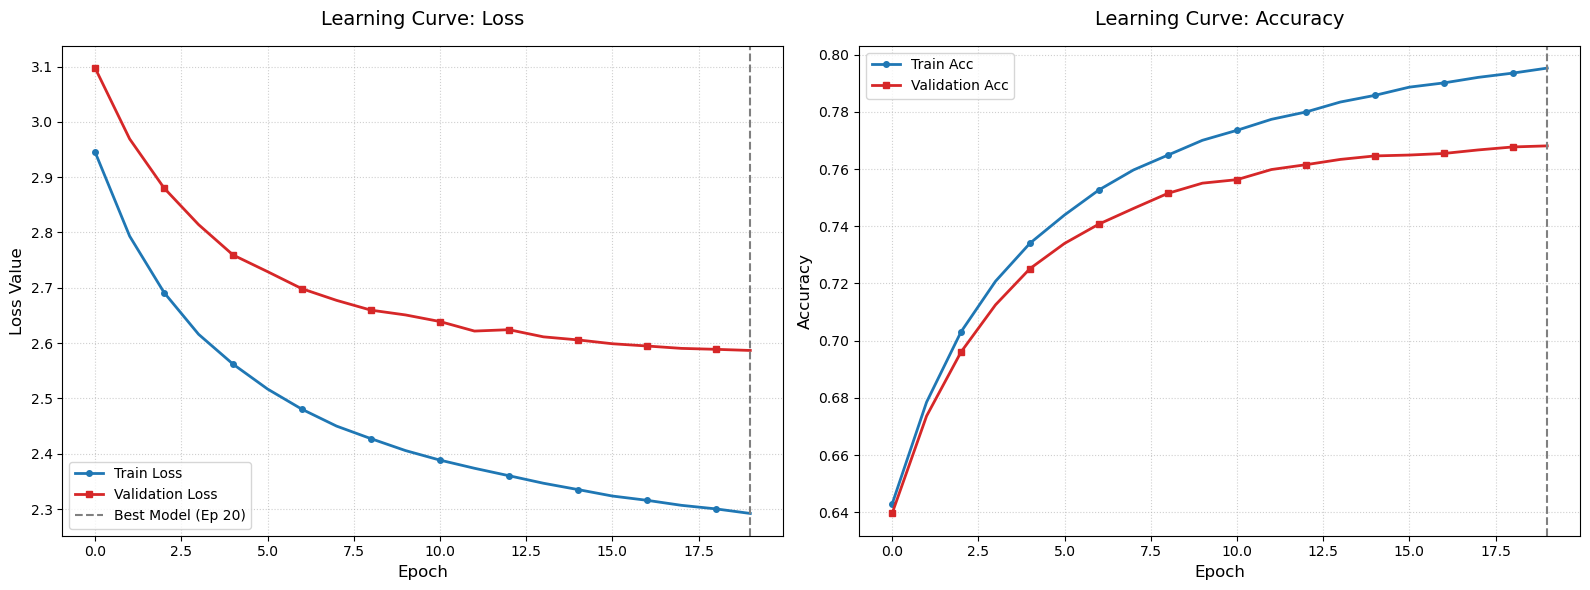

In [46]:
# 학습 곡선 시각화
plt.style.use('seaborn-v0_8-muted') # 그래프 스타일 설정
plt.figure(figsize=(16, 6))

# 학습 결과 데이터 연결 (history 딕셔너리 사용)
t_loss = history['train_loss']
v_loss = history['val_loss']
t_acc = history['train_acc']
v_acc = history['val_acc']

# Best Epoch 찾기 (그래프에 표시하기 위함)
best_epoch = np.argmin(v_loss) # 가장 낮은 val_loss의 인덱스

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(t_loss, label='Train Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4, markevery=2)
plt.plot(v_loss, label='Validation Loss', color='#d62728', linewidth=2, marker='s', markersize=4, markevery=2)
plt.axvline(x=best_epoch, color='gray', linestyle='--', label=f'Best Model (Ep {best_epoch+1})') 
plt.title('Learning Curve: Loss', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(t_acc, label='Train Acc', color='#1f77b4', linewidth=2, marker='o', markersize=4, markevery=2)
plt.plot(v_acc, label='Validation Acc', color='#d62728', linewidth=2, marker='s', markersize=4, markevery=2)
plt.axvline(x=best_epoch, color='gray', linestyle='--')
plt.title('Learning Curve: Accuracy', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(HOME_DIR+'gpt_learning_result.png', dpi=300) # 그래프 저장

## 9. 모델 평가

학습 과정에서 최고 정확도를 보인 모델을 불러와서 실제 대화를 이어가며 챗봇의 추론 성능을 평가한다.

In [47]:
# 가장 좋았던 모델 가중치 불러오기
model.load_state_dict(torch.load('gpt1_best_model.pth'))
model.to(device)
model.eval()

GPT1(
  (token_embedding): Embedding(8000, 256)
  (pos_encoding): PositionalEncoding(
    (pos_embedding): Embedding(64, 256)
  )
  (transformer_blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (attention): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=True)
        (W_k): Linear(in_features=256, out_features=256, bias=True)
        (W_v): Linear(in_features=256, out_features=256, bias=True)
        (W_o): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): PositionwiseFeedForward(
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )

In [48]:
# 테스트할 질문 리스트
test_questions = [
    "오늘 기분이 어때?",
    "오늘 날씨 어때?",
    "배가 너무 고파요",
    "여행 가고 싶다",
    "너는 누구니?",
    "우리 오늘 공부 열심히 했다!"
]

In [49]:
print("\n🤖 GPT-1 챗봇 테스트 시작!")
print("=" * 40)

for q in test_questions:
    # 우리가 만든 sentence_generation 함수 사용
    answer = sentence_generation(model, q, sp, device=device)
    print("-" * 40)


🤖 GPT-1 챗봇 테스트 시작!
입력 : 오늘 기분이 어때?
출력 : 무슨 계기가 있었을지도 몰라요.
----------------------------------------
입력 : 오늘 날씨 어때?
출력 : 저도 보고 싶어요.
----------------------------------------
입력 : 배가 너무 고파요
출력 : 뭐 좀
----------------------------------------
입력 : 여행 가고 싶다
출력 : 계획을 세워보세요.
----------------------------------------
입력 : 너는 누구니?
출력 : 저는 마음을 이어주는 위로봇입니다.
----------------------------------------
입력 : 우리 오늘 공부 열심히 했다!
출력 : 신청했더니 정말로 신청했더니 왔네 칼로리!
----------------------------------------


## 정리

- **모델 아키텍처 요약 (`model.summary`)**

  * 구조: Decoder-only Transformer 기반 GPT-1 아키텍처
    
  * 규모: 총 4개의 Transformer Block 사용 ((0-3): 4 x TransformerBlock)
 
  * 차원: Embedding 및 Hidden 차원 256, FeedForward 차원 512
 
  * 어텐션: 8-Head Multi-Head Attention 적용
 
  * 단어 임베딩: SentencePiece 기반 8,000 토큰 임베딩 레이어 구성
 
---

  ```
  GPT1(
  (token_embedding): Embedding(8000, 256)
  (pos_encoding): PositionalEncoding(
    (pos_embedding): Embedding(64, 256)
  )
  (transformer_blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (attention): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=True)
        (W_k): Linear(in_features=256, out_features=256, bias=True)
        (W_v): Linear(in_features=256, out_features=256, bias=True)
        (W_o): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): PositionwiseFeedForward(
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=256, out_features=8000, bias=False)
  (dropout): Dropout(p=0.1, inplace=False)
)
```

- **모델 학습 결과 (`model.fit`)**

  * 위 학습 로그 참고
  * 20 에폭 학습 결과, 최종 에폭에서 가장 낮은 val loss (`2.5867`) 와 가장 높은 val accuracy (`76.81%`) 달성
  * 학습 곡선 그래프 확인 결과, Train/Val Loss가 동반 하락하며 심각한 과적합 없이 안정적으로 수렴

- **정성적 평가**

  * "너는 누구니?"라는 질문에 "마음을 이어주는 위로봇"이라고 답변하여 모델의 의도 학습이 성공적임을 확인
  * 일상적인 질문(여행, 기분 등)에 대해 문법적으로 올바르고 문맥에 부합하는 답변 생성 가능
  * 학습 데이터에 없던 질문에는 답변을 잘 못함